# Домашнее задание по теме "Рекурентные сети 2"

In [90]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import torch
from torch import nn
import re
import random
import tqdm
import time

## Задание 1

Сгенерировать последовательности, которые бы состояли из цифр (от 0 до 9)
и задавались следующим образом:

x - последовательность цифр

y1 = x1, y(i) = x(i) + x(1). Если y(i) >= 10, то y(i) = y(i) - 10

**Задача:**
научить модель предсказывать y(i) по x(i)
пробовать RNN, LSTM, GRU

## Генерация последовательностей

1. Генерируем матрицу последовательностей 100_000 x 50
1. На основе исходной матрицы X создадим матрицу Y в соответствии с условием

In [91]:
n = 100_000 # колисество последовательностей
m = 50 # длина каждой последовательности

X = np.random.randint(0, 10, size=(n, m))
print(X.shape)
print(X[: 2, :])

(100000, 50)
[[4 9 0 4 6 5 2 7 9 3 4 2 3 4 4 9 1 0 6 8 0 4 8 1 7 6 5 5 1 1 7 5 3 4 1 0
  9 3 8 2 8 8 3 2 0 7 9 1 7 3]
 [1 5 9 9 7 6 5 4 3 0 8 0 4 2 5 2 2 8 8 6 9 6 5 2 7 1 3 2 6 9 7 0 1 6 8 3
  7 4 7 4 0 0 3 1 7 8 5 3 4 8]]


Функция создания мартицы Y

In [92]:
def transform_matrix(X):
    x1 = X[:, 0].reshape(-1, 1)
    Y = (X + x1) % 10
    Y[:, 0] = X[:, 0]

    return Y

In [93]:
Y = transform_matrix(X)
print(Y[:2, :])

[[4 3 4 8 0 9 6 1 3 7 8 6 7 8 8 3 5 4 0 2 4 8 2 5 1 0 9 9 5 5 1 9 7 8 5 4
  3 7 2 6 2 2 7 6 4 1 3 5 1 7]
 [1 6 0 0 8 7 6 5 4 1 9 1 5 3 6 3 3 9 9 7 0 7 6 3 8 2 4 3 7 0 8 1 2 7 9 4
  8 5 8 5 1 1 4 2 8 9 6 4 5 9]]


## Подготовка датасета

1. Разбиваем датасет на тестовую и обучающую выборки
1. Превращаем numpy массивы в тензоры
1. Разбиваем на батчи

In [94]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

In [95]:
train_dataset = torch.utils.data.TensorDataset(
    torch.LongTensor(X_train),
    torch.LongTensor(Y_train)
)

test_dataset = torch.utils.data.TensorDataset(
    torch.LongTensor(X_test),
    torch.LongTensor(Y_test)
)

In [96]:
BATCH_SIZE = 512

In [97]:
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

## Архитектура нейросети

In [98]:
class NeuralNetwork(nn.Module):
    def __init__(self, rnnClass, dictionary_size, embedding_size, num_hiddens, num_classes):
        super().__init__()

        self.num_hiddens = num_hiddens
        self.embedding = nn.Embedding(dictionary_size, embedding_size)
        self.rnn = rnnClass(embedding_size, num_hiddens, batch_first=True)
        self.output = nn.Linear(num_hiddens, num_classes)

    def forward(self, X):
        out = self.embedding(X)
        rnn_out, _ = self.rnn(out)
        prediction = self.output(rnn_out)
        # _, state = self.hidden(out)
        # prediction = self.output(state[0].squeeze())
        return prediction

## Вспомогательные функции

Функция обучения модели

In [99]:
def train_model(model, train_loader, test_loader, optimizer, criterion, num_epochs=30):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    
    history = {
            'train_loss': [],
            'test_loss': [],
            'train_acc': [],
            'test_acc': []
        }

    for ep in range(num_epochs):
        start = time.time()
        
        # --- ФАЗА ОБУЧЕНИЯ ---
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            
            optimizer.zero_grad()
            outputs = model(X_b)
            loss = criterion(outputs.view(-1, 10), y_b.view(-1))
            
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            preds = outputs.argmax(dim=-1) 
            train_correct += (preds == y_b).sum().item()
            train_total += y_b.numel()

        # --- ФАЗА ТЕСТИРОВАНИЯ ---
        model.eval()
        test_loss = 0.0
        test_correct = 0
        test_total = 0
        
        with torch.no_grad():
            for X_t, y_t in test_loader:
                X_t, y_t = X_t.to(device), y_t.to(device)
                
                outputs_t = model(X_t)
                loss_t = criterion(outputs_t.view(-1, 10), y_t.view(-1))
                
                test_loss += loss_t.item()
                preds_t = outputs_t.argmax(dim=-1)
                test_correct += (preds_t == y_t).sum().item()
                test_total += y_t.numel()

        # Вычисление средних значений
        avg_train_loss = train_loss / len(train_loader)
        avg_test_loss = test_loss / len(test_loader)
        train_acc = 100 * train_correct / train_total
        test_acc = 100 * test_correct / test_total
        
        epoch_time = time.time() - start

        history['train_loss'].append(avg_train_loss)
        history['test_loss'].append(avg_test_loss)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)
        
        print(f"Epoch {ep+1:2d} | Time: {epoch_time:.2f}s")
        print(f"  [Train] Loss: {avg_train_loss:.4f}, Acc: {train_acc:.2f}%")
        print(f"  [Test ] Loss: {avg_test_loss:.4f}, Acc: {test_acc:.2f}%")
        print("-" * 40)

    return history    

Функция визуального представления изменения Loss

In [100]:
import matplotlib.pyplot as plt

def plot_history(history):
    epochs = range(1, len(history['train_loss']) + 1)
    
    plt.figure(figsize=(15, 5)) # Задаем размер всего полотна

    # График 1: Loss
    plt.subplot(1, 2, 1) # 1 строка, 2 колонки, индекс 1
    plt.plot(epochs, history['train_loss'], 'b-o', label='Train Loss')
    plt.plot(epochs, history['test_loss'], 'r-o', label='Test Loss')
    plt.title('Изменение Loss по эпохам')
    plt.xlabel('Эпохи')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # График 2: Accuracy
    plt.subplot(1, 2, 2) # 1 строка, 2 колонки, индекс 2
    plt.plot(epochs, history['train_acc'], 'b-s', label='Train Acc')
    plt.plot(epochs, history['test_acc'], 'r-s', label='Test Acc')
    plt.title('Изменение Accuracy (%) по эпохам')
    plt.xlabel('Эпохи')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)

    plt.tight_layout() # Чтобы графики не наезжали друг на друга
    plt.show()

## Обучение моделей

### Обучение RNN модели

In [101]:
DICT_SIZE = 10
EMBEDDING_SIZE = 16
NUM_HIDDENS = 128
MODEL_TYPE = nn.RNN

Инициализируем модели

In [102]:
model = NeuralNetwork(MODEL_TYPE, DICT_SIZE, EMBEDDING_SIZE, NUM_HIDDENS, DICT_SIZE)

In [103]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters())

Обучение модели

In [72]:
history = train_model(model, train_loader, test_loader, optimizer, criterion)

Epoch  1 | Time: 0.51s
  [Train] Loss: 2.3017, Acc: 11.74%
  [Test ] Loss: 2.3015, Acc: 11.69%
----------------------------------------
Epoch  2 | Time: 0.50s
  [Train] Loss: 2.3007, Acc: 11.94%
  [Test ] Loss: 2.2989, Acc: 12.08%
----------------------------------------
Epoch  3 | Time: 0.58s
  [Train] Loss: 2.0529, Acc: 19.70%
  [Test ] Loss: 1.8157, Acc: 21.73%
----------------------------------------
Epoch  4 | Time: 0.51s
  [Train] Loss: 1.5399, Acc: 31.46%
  [Test ] Loss: 1.1738, Acc: 41.48%
----------------------------------------
Epoch  5 | Time: 0.51s
  [Train] Loss: 1.0832, Acc: 42.28%
  [Test ] Loss: 1.0401, Acc: 42.96%
----------------------------------------
Epoch  6 | Time: 0.51s
  [Train] Loss: 1.2183, Acc: 41.89%
  [Test ] Loss: 1.4107, Acc: 40.34%
----------------------------------------
Epoch  7 | Time: 0.51s
  [Train] Loss: 1.1007, Acc: 42.61%
  [Test ] Loss: 1.0282, Acc: 43.01%
----------------------------------------
Epoch  8 | Time: 0.58s
  [Train] Loss: 1.0220, A

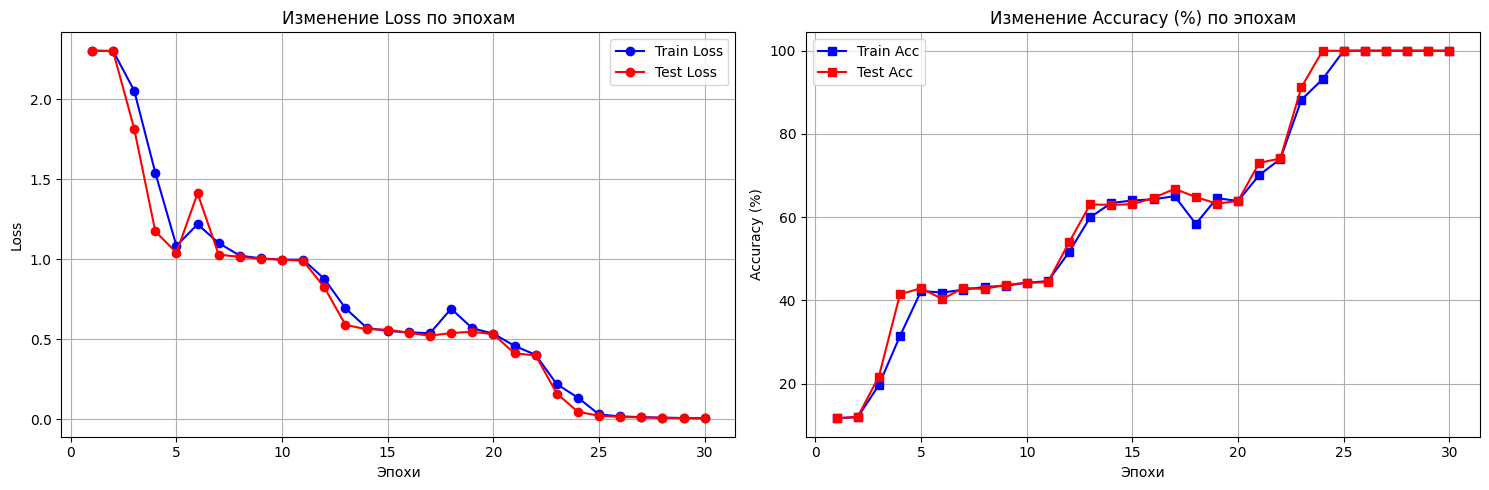

In [73]:
plot_history(history)

### Обучение LSTM модели

In [74]:
DICT_SIZE = 10
EMBEDDING_SIZE = 16
NUM_HIDDENS = 128
MODEL_TYPE = nn.LSTM

Инициализация модели

In [75]:
model = NeuralNetwork(MODEL_TYPE, DICT_SIZE, EMBEDDING_SIZE, NUM_HIDDENS, DICT_SIZE)

In [76]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters())

Обучение модели

Epoch  1 | Time: 1.48s
  [Train] Loss: 2.2247, Acc: 14.67%
  [Test ] Loss: 1.8862, Acc: 21.87%
----------------------------------------
Epoch  2 | Time: 1.49s
  [Train] Loss: 1.6964, Acc: 22.56%
  [Test ] Loss: 1.5868, Acc: 27.53%
----------------------------------------
Epoch  3 | Time: 1.56s
  [Train] Loss: 1.0482, Acc: 45.44%
  [Test ] Loss: 0.7238, Acc: 55.54%
----------------------------------------
Epoch  4 | Time: 1.47s
  [Train] Loss: 0.6680, Acc: 58.82%
  [Test ] Loss: 0.5771, Acc: 69.97%
----------------------------------------
Epoch  5 | Time: 1.47s
  [Train] Loss: 0.3996, Acc: 83.72%
  [Test ] Loss: 0.2148, Acc: 94.93%
----------------------------------------
Epoch  6 | Time: 1.48s
  [Train] Loss: 0.0686, Acc: 99.79%
  [Test ] Loss: 0.0274, Acc: 99.99%
----------------------------------------
Epoch  7 | Time: 1.48s
  [Train] Loss: 0.0180, Acc: 100.00%
  [Test ] Loss: 0.0125, Acc: 100.00%
----------------------------------------
Epoch  8 | Time: 1.55s
  [Train] Loss: 0.0094,

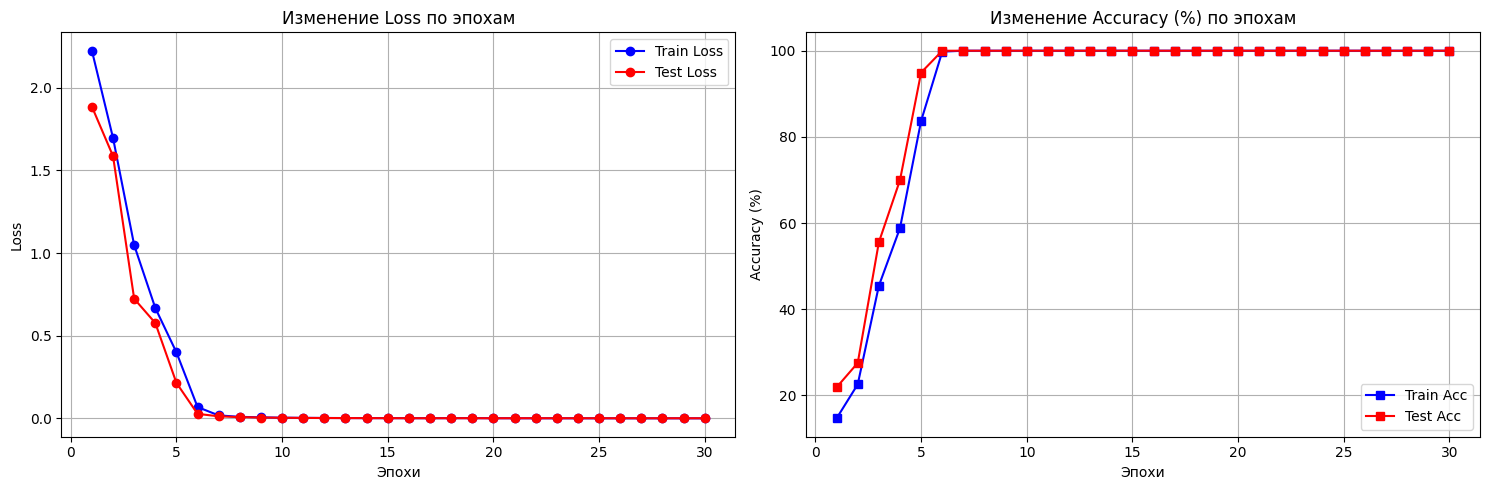

In [77]:
history = train_model(model, train_loader, test_loader, optimizer, criterion)
plot_history(history)

### Обучение GRU модели

In [104]:
DICT_SIZE = 10
EMBEDDING_SIZE = 16
NUM_HIDDENS = 128
MODEL_TYPE = nn.GRU

Инициализация модели

In [105]:
model = NeuralNetwork(MODEL_TYPE, DICT_SIZE, EMBEDDING_SIZE, NUM_HIDDENS, DICT_SIZE)

In [106]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters())

Обучение модели

Epoch  1 | Time: 1.00s
  [Train] Loss: 2.2969, Acc: 11.94%
  [Test ] Loss: 2.2379, Acc: 17.58%
----------------------------------------
Epoch  2 | Time: 0.91s
  [Train] Loss: 1.2440, Acc: 61.87%
  [Test ] Loss: 0.2900, Acc: 99.65%
----------------------------------------
Epoch  3 | Time: 0.92s
  [Train] Loss: 0.1154, Acc: 99.95%
  [Test ] Loss: 0.0446, Acc: 100.00%
----------------------------------------
Epoch  4 | Time: 0.91s
  [Train] Loss: 0.0285, Acc: 100.00%
  [Test ] Loss: 0.0185, Acc: 100.00%
----------------------------------------
Epoch  5 | Time: 0.93s
  [Train] Loss: 0.0139, Acc: 100.00%
  [Test ] Loss: 0.0105, Acc: 100.00%
----------------------------------------
Epoch  6 | Time: 0.98s
  [Train] Loss: 0.0084, Acc: 100.00%
  [Test ] Loss: 0.0068, Acc: 100.00%
----------------------------------------
Epoch  7 | Time: 0.91s
  [Train] Loss: 0.0057, Acc: 100.00%
  [Test ] Loss: 0.0047, Acc: 100.00%
----------------------------------------
Epoch  8 | Time: 0.91s
  [Train] Loss: 

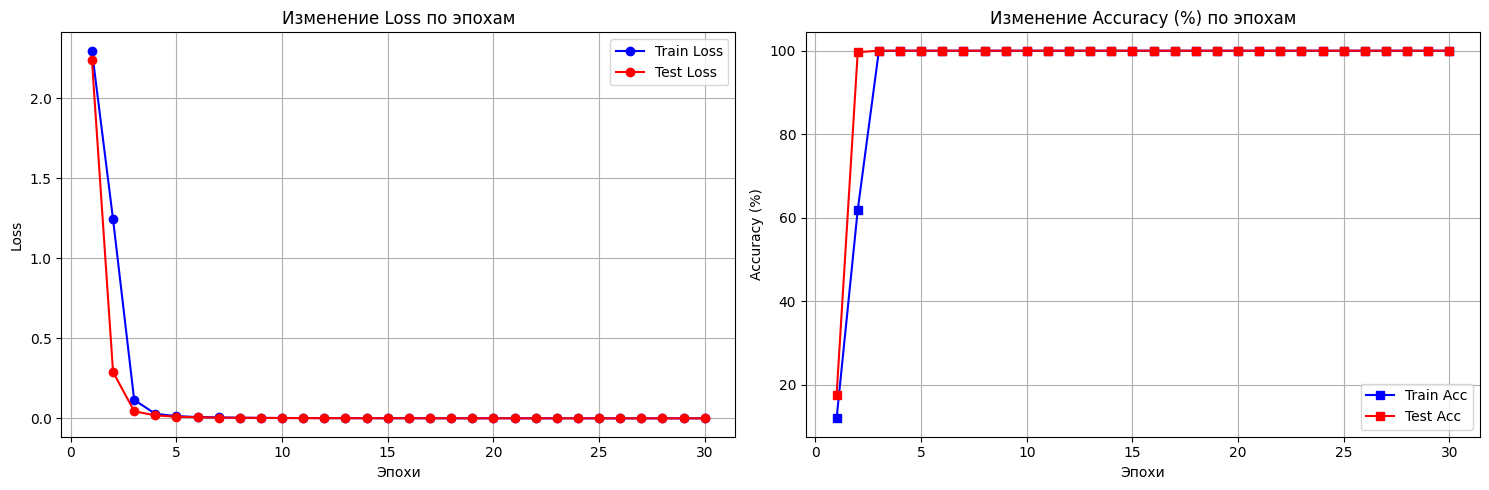

In [107]:
history = train_model(model, train_loader, test_loader, optimizer, criterion)
plot_history(history)

### Заключение:

GRU и LSTM модели быстрее справляются с решением математических задач определения значений последовательности.

## Задание 2
применить LSTM для решения лекционного практического задания

### Получение и предобработка данных

Первичная предобработка текста

In [78]:
with open('nietzsche.txt', encoding='utf-8') as f:
    text = f.read().lower()
print('length:', len(text))    
text = re.sub('[^a-z]', ' ', text)
text = re.sub('\s+', ' ', text)

length: 600893


Создаем словарь из токенов (символов)

In [79]:
INDEX_TO_CHAR = sorted(list(set(text)))
CHAR_TO_INDEX = {c: i for i, c in enumerate(INDEX_TO_CHAR)}

Генерируем предложения датасета

In [80]:
MAX_LEN = 40
STEP = 3
SENTENCES = []
NEXT_CHARS = []

for i in range(0, len(text) - MAX_LEN, STEP):
    SENTENCES.append(text[i: i + MAX_LEN])
    NEXT_CHARS.append(text[i + MAX_LEN])
print('Num sents:', len(SENTENCES))   

Num sents: 193075


Кодируем токены числами и в pythorch векторы

In [81]:
print('Vectorization...')
X = torch.zeros((len(SENTENCES), MAX_LEN), dtype=int) # размер ваборки * длина предложения
Y = torch.zeros((len(SENTENCES)),dtype=int) # размер выборки

for i, sentence in enumerate(SENTENCES):
    for t, char in enumerate(sentence):
        X[i, t] = CHAR_TO_INDEX[char]
    Y[i] = CHAR_TO_INDEX[NEXT_CHARS[i]] 

Vectorization...


Упаковываем предложения в батчи

In [82]:
BATCH_SIZE = 512
dataset = torch.utils.data.TensorDataset(X, Y)
data = torch.utils.data.DataLoader(
    dataset=dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

### Архитектура нейросери

In [83]:
class NeuralNetwork(nn.Module):
    def __init__(self, rnnClass, dictionary_size, embedding_size, num_hiddens, num_classes):
        super().__init__()

        self.num_hiddens = num_hiddens
        self.embedding = nn.Embedding(dictionary_size, embedding_size)
        self.hidden = rnnClass(embedding_size, num_hiddens, batch_first=True)
        self.output = nn.Linear(num_hiddens, num_classes)

    def forward(self, X):
        out = self.embedding(X)
        _, state = self.hidden(out)
        prediction = self.output(state[0].squeeze())
        return prediction

Инициализируем модель с LSTM слоем

In [84]:
model = NeuralNetwork(nn.LSTM, len(CHAR_TO_INDEX), 64, 128, len(CHAR_TO_INDEX))

In [85]:
model = model.cuda()

Функция для семплирования токенов

In [86]:
def sample(preds):
    softmaxed = torch.softmax(preds, 0)
    probas = torch.distributions.multinomial.Multinomial(1, softmaxed).sample()
    return probas.argmax()

Функция генерации текста

In [87]:
def generate_text():
    # Берем случайный отрезок текста нужной длины
    start_index = random.randint(0, len(text) - MAX_LEN - 1)

    generated = ''
    sentence = text[start_index: start_index + MAX_LEN]
    generated += sentence

    # Кодируем токены числами
    for i in range(MAX_LEN):
        x_pred = torch.zeros((1, MAX_LEN), dtype=int)
        for t, char in enumerate(generated[-MAX_LEN:]):
            x_pred[0, t] = CHAR_TO_INDEX[char]
        # предсказываем следующий символ
        preds = model(x_pred.cuda()).cpu()
        next_char = INDEX_TO_CHAR[sample(preds)]    
        generated = generated + next_char

    print(generated[:MAX_LEN] + '|' + generated[MAX_LEN:])   

### Обучение модели

In [88]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters())

In [89]:
for ep in range(30):
    start = time.time()
    train_loss = 0.
    train_passed = 0

    model.train()
    for X_b, y_b in data:
        X_b, y_b = X_b.cuda(), y_b.cuda()
        optimizer.zero_grad()
        answer = model(X_b)
        loss = criterion(answer, y_b)
        train_loss += loss.item()

        loss.backward()
        optimizer.step()
        train_passed += 1

    print("Epoch {}. Time: {:.3f}, Train loss: {:.3f}".format(ep, time.time() - start, train_loss / train_passed))    
    model.eval()
    generate_text()

Epoch 0. Time: 2.504, Train loss: 2.171
 characteristic english taint of spleen |jhisied pomend thich thlene in it hint h
Epoch 1. Time: 2.491, Train loss: 1.786
 its own account my memory the memory of| lor in the word maturio uppesion wist f
Epoch 2. Time: 2.422, Train loss: 1.646
 his nature freedom therefore to be thus| budid phas al them belied subexted sorf
Epoch 3. Time: 2.492, Train loss: 1.562
 are as yet in too close juxtaposition t|his gon thy sarvive by maswer laloig in 
Epoch 4. Time: 2.501, Train loss: 1.503
f bearing robust children they wish to c|are an how seess the fored nvictanss and
Epoch 5. Time: 2.416, Train loss: 1.458
e eager riders who enjoy horseback exerc|ise is in elper worth and ham beliem of 
Epoch 6. Time: 2.482, Train loss: 1.423
rouses fear according to master morality| own the disputical with hid domgation i
Epoch 7. Time: 2.485, Train loss: 1.394
even in every desire for knowledge there| only jisyss readly non it itself not fo
Epoch 8. Time: 2.447, Tr